In [1]:
import json
import math
import os
import gc
import itertools
from functools import partial
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy

from PIL import Image
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras import layers, backend as K
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dropout, Flatten, Dense, GlobalAveragePooling2D, Average,
    Input, Concatenate, GlobalMaxPooling2D, BatchNormalization
)
from tensorflow.keras.callbacks import Callback, ModelCheckpoint, ReduceLROnPlateau, TensorBoard
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.mobilenet import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.metrics import cohen_kappa_score, accuracy_score
from sklearn import metrics

%matplotlib inline

2026-06-06 14:42:33.120398: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780756953.332599      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780756953.393687      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780756953.928533      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780756953.928579      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780756953.928582      23 computation_placer.cc:177] computation placer alr

In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf

# Disable XLA
tf.config.optimizer.set_jit(False)

In [3]:
def Dataset_loader_recursive(DIR, RESIZE):
    IMG = []
    
    for root, _, files in os.walk(DIR):
        for file in files:
            PATH = os.path.join(root, file)
            _, ftype = os.path.splitext(PATH)
            
            if ftype.lower() in [".jpg", ".jpeg", ".png"]:
                try:
                    img = np.asarray(Image.open(PATH).convert("RGB"))
                    img = cv2.resize(img, (RESIZE, RESIZE))
                    IMG.append(img)
                except:
                    continue
    
    return np.array(IMG)
DIR = "/kaggle/input/datasets/tueoban/aisslab-breast-cancer-sub-datasets/AISSLab Sub-datasets/Raw Sub-datasets/AISSLab-v5"

benign_bi_rads_2 = Dataset_loader_recursive(os.path.join(DIR, "BI-RADS 2"), RESIZE=224)
benign_bi_rads_3 = Dataset_loader_recursive(os.path.join(DIR, "BI-RADS 3"), RESIZE=224)

malignant_bi_rads_4 = Dataset_loader_recursive(os.path.join(DIR, "BI-RADS 4"), RESIZE=224)
malignant_bi_rads_5 = Dataset_loader_recursive(os.path.join(DIR, "BI-RADS 5"), RESIZE=224)

#normal = Dataset_loader_recursive(os.path.join(DIR, "Normal/JPG/"), RESIZE=224)

In [4]:
print("Total images loaded:", len(benign_bi_rads_2))
print("Shape:", benign_bi_rads_2.shape)

print("Total images loaded:", len(benign_bi_rads_3))
print("Shape:", benign_bi_rads_3.shape)

print("Total images loaded:", len(malignant_bi_rads_4))
print("Shape:", malignant_bi_rads_4.shape)

print("Total images loaded:", len(malignant_bi_rads_5))
print("Shape:", malignant_bi_rads_5.shape)

Total images loaded: 18
Shape: (18, 224, 224, 3)
Total images loaded: 48
Shape: (48, 224, 224, 3)
Total images loaded: 54
Shape: (54, 224, 224, 3)
Total images loaded: 46
Shape: (46, 224, 224, 3)


In [5]:
#normal_label = np.full(len(normal),0)
benign_bi_rads_2_label = np.full(len(benign_bi_rads_2), 0)
benign_bi_rads_3_label = np.full(len(benign_bi_rads_3),1)
malignant_bi_rads_4_label = np.full(len(malignant_bi_rads_4),2)
malignant_bi_rads_5_label = np.full(len(malignant_bi_rads_5),3)

In [6]:
X = np.concatenate((benign_bi_rads_2, benign_bi_rads_3, malignant_bi_rads_4, malignant_bi_rads_5), axis = 0)
Y = np.concatenate((benign_bi_rads_2_label, benign_bi_rads_3_label, malignant_bi_rads_4_label, malignant_bi_rads_5_label), axis = 0)

# Shuffle train data
s = np.arange(X.shape[0])
np.random.shuffle(s)
X = X[s]
Y = Y[s]

# MOBILENET PREPROCESSING
X = preprocess_input(
    X.astype("float32")
)
x_train, x_test, y_train, y_test = train_test_split(
    X, Y, 
    test_size=0.2, 
    random_state=11,
    stratify=Y
)

In [7]:
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, 
    test_size=0.2, 
    random_state=11,
    stratify=y_train
)
print("\nFinal Shapes:")
print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_val:", x_val.shape)
print("y_val:", y_val.shape)
print("x_test:", x_test.shape)
print("y_test:", y_test.shape)


Final Shapes:
x_train: (105, 224, 224, 3)
y_train: (105,)
x_val: (27, 224, 224, 3)
y_val: (27,)
x_test: (34, 224, 224, 3)
y_test: (34,)


In [8]:
from imblearn.over_sampling import RandomOverSampler
from tensorflow.keras.utils import to_categorical
from collections import Counter
import numpy as np

# -----------------------------
# Convert one-hot -> labels if needed
# -----------------------------
if len(y_train.shape) > 1:
    y_train_labels = np.argmax(y_train, axis=1)
else:
    y_train_labels = y_train

# -----------------------------
# Check original distribution
# -----------------------------
print("Original class distribution:")
print(Counter(y_train_labels))

# -----------------------------
# Flatten image data temporarily
# -----------------------------
nsamples, h, w, c = x_train.shape

x_train_flat = x_train.reshape(
    (nsamples, h * w * c)
)

target = 1200
# -----------------------------
# Target: 100 samples per class
# -----------------------------
sampling_strategy = {
    0: target,
    1: target,
    2: target,
    3: target
}

# -----------------------------
# Apply Oversampling
# -----------------------------
ros = RandomOverSampler(
    sampling_strategy=sampling_strategy,
    random_state=42
)

x_train, y_train = ros.fit_resample(
    x_train_flat,
    y_train_labels
)

# -----------------------------
# Restore image shape
# -----------------------------
x_train = x_train.reshape(
    (-1, h, w, c)
)

# -----------------------------
# One-hot Encode Labels
# -----------------------------
y_train = to_categorical(
    y_train,
    num_classes=4
)

# Validation labels
if len(y_val.shape) == 1:
    y_val = to_categorical(y_val, num_classes=4)

# Test labels
if len(y_test.shape) == 1:
    y_test = to_categorical(y_test, num_classes=4)

# -----------------------------
# Final Distribution
# -----------------------------
print("\nBalanced class distribution:")
print(Counter(np.argmax(y_train, axis=1)))

Original class distribution:
Counter({np.int64(2): 34, np.int64(3): 30, np.int64(1): 30, np.int64(0): 11})

Balanced class distribution:
Counter({np.int64(2): 1200, np.int64(3): 1200, np.int64(0): 1200, np.int64(1): 1200})


In [9]:
BATCH_SIZE = 32

# Using original generator
train_generator = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=False
)

In [10]:
IMAGE_SIZE = 224

# Input
input_shape = (IMAGE_SIZE, IMAGE_SIZE, 3)
inputs = Input(shape=input_shape)

# PRETRAINED MOBILENET (V1)
mobilenet = MobileNet(
    weights="imagenet",
    include_top=False,
    input_tensor=inputs
)

/tmp/ipykernel_23/878216123.py:8: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = MobileNet(
I0000 00:00:1780757010.394052      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780757010.400375      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
# FREEZE
for layer in mobilenet.layers:
    layer.trainable = False

In [12]:
# CLASSIFIER HEAD
x = mobilenet.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(256,activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
outputs = Dense(4,activation='softmax')(x)

# FINAL MODEL
model = Model(inputs,outputs)

In [13]:
# COMPILE
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,497,412 (13.34 MB)

 Trainable params: 265,988 (1.01 MB)

 Non-trainable params: 3,231,424 (12.33 MB)

In [14]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

filepath = "/kaggle/working/best_AISSlab.keras"

checkpoint = ModelCheckpoint(
    filepath,
    monitor='val_accuracy', 
    verbose=1,
    save_best_only=True,
    mode='max'
)

# Early stopping
early_stopping = EarlyStopping(
    monitor='val_accuracy',   
    patience=8,             
    verbose=1,
    mode='max',
    restore_best_weights=True
)

# LR 
learn_control = ReduceLROnPlateau(
    monitor='val_loss',
    patience=3,
    factor=0.3,
    min_lr=1e-6,
    verbose=1
)

In [15]:
history = model.fit(
    train_generator.flow(x_train, y_train, batch_size=BATCH_SIZE),
    steps_per_epoch=x_train.shape[0] // BATCH_SIZE,
    epochs=30,
    validation_data=(x_val, y_val),
    callbacks=[checkpoint, early_stopping, learn_control]
)

Epoch 1/30


I0000 00:00:1780757017.347930      69 service.cc:152] XLA service 0x79a94412b5f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780757017.347985      69 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780757017.347991      69 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780757018.230258      69 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-06 14:43:46.718993: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 14:43:46.857479: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1780757029.298416      69 device_co

150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.3175 - loss: 1.9946

2026-06-06 14:44:44.502378: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 14:44:44.640762: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from None to 0.29630, saving model to /kaggle/working/best_AISSlab.keras

Epoch 1: finished saving model to /kaggle/working/best_AISSlab.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 74s 381ms/step - accuracy: 0.3638 - loss: 1.8012 - val_accuracy: 0.2963 - val_loss: 1.5141 - learning_rate: 1.0000e-04
Epoch 2/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.4726 - loss: 1.4045
Epoch 2: val_accuracy improved from 0.29630 to 0.37037, saving model to /kaggle/working/best_AISSlab.keras

Epoch 2: finished saving model to /kaggle/working/best_AISSlab.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 47s 313ms/step - accuracy: 0.5046 - loss: 1.3350 - val_accuracy: 0.3704 - val_loss: 1.6073 - learning_rate: 1.0000e-04
Epoch 3/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.5579 - loss: 1.1408
Epoch 3: val_accuracy did not improve from 0.37037
150/150 ━━━━━━━━━━━━━━━━━━━━ 48s 318ms/step - accuracy: 0.5813 - loss: 1.0846 - val_accuracy: 0.2593 - val_loss: 1.7544 - lea

In [16]:
# UNFREEZE LAST 20 LAYERS
for layer in mobilenet.layers[-20:]:
    layer.trainable = True

In [17]:
# RECOMPILE

model.compile(
    optimizer=Adam(
        learning_rate=1e-5
    ),

    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
history_fine = model.fit(
    train_generator.flow(
        x_train,
        y_train,
        batch_size=BATCH_SIZE
    ),
    steps_per_epoch=x_train.shape[0] // BATCH_SIZE,
    epochs=50,
    validation_data=(x_val, y_val),
    callbacks=[
        checkpoint,
        early_stopping,
        learn_control
    ]
)

Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.4746 - loss: 1.3699
Epoch 1: val_accuracy did not improve from 0.37037
150/150 ━━━━━━━━━━━━━━━━━━━━ 61s 320ms/step - accuracy: 0.4919 - loss: 1.3177 - val_accuracy: 0.3704 - val_loss: 1.5227 - learning_rate: 1.0000e-05
Epoch 2/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.5418 - loss: 1.2007
Epoch 2: val_accuracy did not improve from 0.37037
150/150 ━━━━━━━━━━━━━━━━━━━━ 47s 313ms/step - accuracy: 0.5567 - loss: 1.1510 - val_accuracy: 0.3704 - val_loss: 1.5347 - learning_rate: 1.0000e-05
Epoch 3/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.6077 - loss: 1.0137
Epoch 3: val_accuracy improved from 0.37037 to 0.40741, saving model to /kaggle/working/best_AISSlab.keras

Epoch 3: finished saving model to /kaggle/working/best_AISSlab.keras

Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
150/150 ━━━━━━━━━━━━━━━━━━━━ 47s 312ms/step - accuracy: 0.6173 - loss: 0.9874 - val

In [19]:
y_pred = model.predict(x_test)

1/2 ━━━━━━━━━━━━━━━━━━━━ 2s 3s/step

2026-06-06 15:00:47.134544: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 15:00:47.293476: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 9s/step


Confusion matrix, without normalization
[[1 0 2 1]
 [1 3 4 2]
 [0 4 7 0]
 [0 1 2 6]]


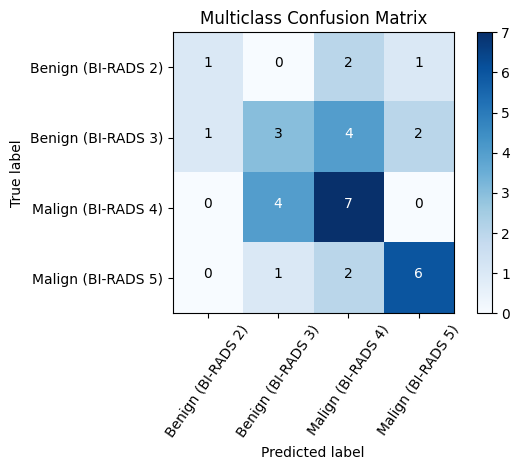

In [20]:
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=55)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

cm = confusion_matrix(np.argmax(y_test, axis=1), np.argmax(y_pred, axis=1))

cm_plot_label =['Benign (BI-RADS 2)', 'Benign (BI-RADS 3)', 'Malign (BI-RADS 4)', 'Malign (BI-RADS 5)']
plot_confusion_matrix(cm, cm_plot_label, title ='Multiclass Confusion Matrix')

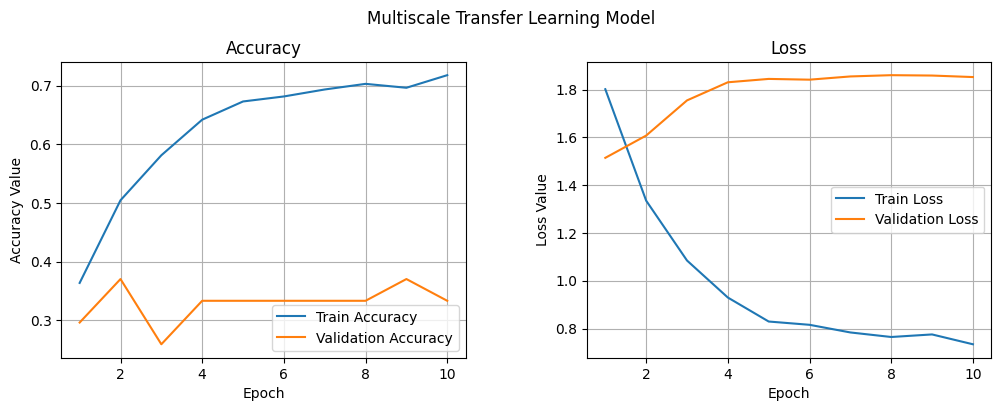

In [21]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

t = f.suptitle('Multiscale Transfer Learning Model', fontsize=12)

f.subplots_adjust(top=0.85, wspace=0.3)

# Dynamic epoch count
epoch_list = range(1, len(history.history['accuracy']) + 1)

# Accuracy Plot
ax1.plot(epoch_list, history.history['accuracy'], label='Train Accuracy')
ax1.plot(epoch_list, history.history['val_accuracy'], label='Validation Accuracy')

ax1.grid()
ax1.set_ylabel('Accuracy Value')
ax1.set_xlabel('Epoch')
ax1.set_title('Accuracy')
ax1.legend(loc="best")

# Loss Plot
ax2.plot(epoch_list, history.history['loss'], label='Train Loss')
ax2.plot(epoch_list, history.history['val_loss'], label='Validation Loss')

ax2.grid()
ax2.set_ylabel('Loss Value')
ax2.set_xlabel('Epoch')
ax2.set_title('Loss')
ax2.legend(loc="best")

plt.show()

In [22]:
print("y_test:", y_test.shape)
print("y_pred:", y_pred.shape)

y_test: (34, 4)
y_pred: (34, 4)


In [23]:
import numpy as np
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    mean_absolute_error,
    mean_squared_error,
    cohen_kappa_score
)

# Predictions
pred = model.predict(x_test)
y_pred = np.argmax(pred, axis=1)
y_test = np.argmax(y_test, axis=1)

# Target labels
target_names = [
    'Benign (BI-RADS 2)',
    'Benign (BI-RADS 3)',
    'Malign (BI-RADS 4)',
    'Malign (BI-RADS 5)'
]

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Additional Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)

# Print all metrics
print("\nAdditional Evaluation Metrics:")
print(f"Accuracy       : {accuracy:.4f}")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1-score       : {f1:.4f}")
print(f"MCC            : {mcc:.4f}")
print(f"MAE            : {mae:.4f}")
print(f"MSE            : {mse:.4f}")
print(f"Cohen's Kappa  : {kappa:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Classification Report:
                    precision    recall  f1-score   support

Benign (BI-RADS 2)       0.50      0.25      0.33         4
Benign (BI-RADS 3)       0.38      0.30      0.33        10
Malign (BI-RADS 4)       0.47      0.64      0.54        11
Malign (BI-RADS 5)       0.67      0.67      0.67         9

          accuracy                           0.50        34
         macro avg       0.50      0.46      0.47        34
      weighted avg       0.50      0.50      0.49        34

Confusion Matrix:
[[1 0 2 1]
 [1 3 4 2]
 [0 4 7 0]
 [0 1 2 6]]

Additional Evaluation Metrics:
Accuracy       : 0.5000
Precision      : 0.4966
Recall         : 0.5000
F1-score       : 0.4879
MCC            : 0.3014
MAE            : 0.7059
MSE            : 1.1765
Cohen's Kappa  : 0.2968
